In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. LOAD AND CLEAN THE DATA
# ==========================================
print("1. Loading the Data...")
df = pd.read_csv('/content/drive/MyDrive/CSE484KnoEng/Atmospheric Retrieval of Exoplanet/Final_ML_Dataset.csv')

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# ==========================================
# 2. SAFE LOG-TRANSFORM FOR CHEMICALS
# ==========================================
print("2. Applying safe log-transforms to chemicals...")
chemical_cols = ['H2O', 'CO2', 'CH4', 'O2', 'CO']
target_columns = ['planet_surface_temperature_(Kelvin)'] + chemical_cols

for col in chemical_cols:
    df[col] = np.clip(df[col], a_min=0, a_max=None)
    df[col] = np.log10(df[col] + 1e-12)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# ==========================================
# 3. SEPARATE X AND y
# ==========================================
print("3. Separating X and y...")
X = df.loc[:, 'bin_0':'bin_199'].values
y = df[target_columns].values

# ==========================================
# 4. SCALING AND SPLITTING
# ==========================================
print("4. Scaling Data (MinMax for X, Standard for y)...")
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

print("5. Splitting and Reshaping for CNN...")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

X_train_cnn = X_train.reshape((X_train.shape[0], 200, 1))
X_test_cnn = X_test.reshape((X_test.shape[0], 200, 1))

# ==========================================
# 6. BUILD THE CNN (FLATTEN RESTORED)
# ==========================================
print("6. Building the Spectroscopic CNN...")

model = Sequential([
    Conv1D(filters=64, kernel_size=5, input_shape=(200, 1)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=3),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=256, kernel_size=3),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # Flatten is back! The AI needs to see EXACTLY where the dips are.
    Flatten(),

    Dense(128),
    LeakyReLU(alpha=0.1),
    Dropout(0.2), # A gentle shock absorber for the outliers

    Dense(len(target_columns), activation='linear')
])

# Locked the learning rate back down to 0.0002
custom_optimizer = Adam(learning_rate=0.0002, clipnorm=1.0)
model.compile(optimizer=custom_optimizer, loss='mse', metrics=['mae'])

# ==========================================
# 7. TRAIN THE MODEL
# ==========================================
print("\n--- Starting Final Training Run ---")

early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=0.00001,
    verbose=1
)

history = model.fit(
    X_train_cnn, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopper, reduce_lr],
    verbose=1
)

1. Loading the Data...
2. Applying safe log-transforms to chemicals...
3. Separating X and y...
4. Scaling Data (MinMax for X, Standard for y)...
5. Splitting and Reshaping for CNN...
6. Building the Spectroscopic CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(



--- Starting Final Training Run ---
Epoch 1/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - loss: 1.2662 - mae: 0.7394 - val_loss: 1.0509 - val_mae: 0.7864 - learning_rate: 2.0000e-04
Epoch 2/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.0939 - mae: 0.6662 - val_loss: 1.1113 - val_mae: 0.8101 - learning_rate: 2.0000e-04
Epoch 3/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8134 - mae: 0.6383 - val_loss: 1.3291 - val_mae: 0.9045 - learning_rate: 2.0000e-04
Epoch 4/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8648 - mae: 0.6198 - val_loss: 1.5410 - val_mae: 0.9942 - learning_rate: 2.0000e-04
Epoch 5/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8029 - mae: 0.6048 - val_loss: 2.4536 - val_mae: 1.2372 - learning_rate: 2.0000e-04
Epoch 6/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9086 - mae: 0.5917 - val_loss: 1.1167 - val_mae: 0.7971 - learning_rate: 2.0000e-04
Epoch 7/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6773 - mae: 0.57

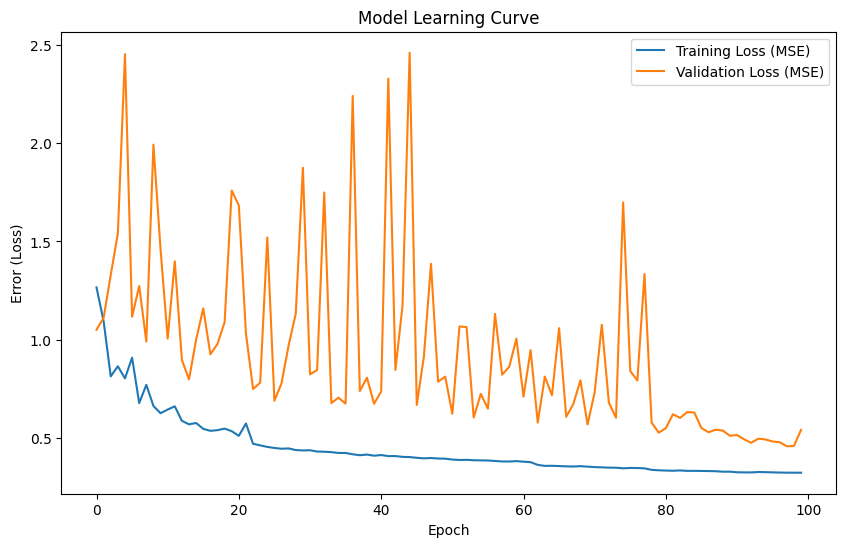

In [37]:
# 8. Plot the New Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('Error (Loss)')
plt.legend()
plt.show()

Generating predictions on unseen test data...
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Overall R-Squared Score: 0.1685 (Closer to 1.0 is better!)


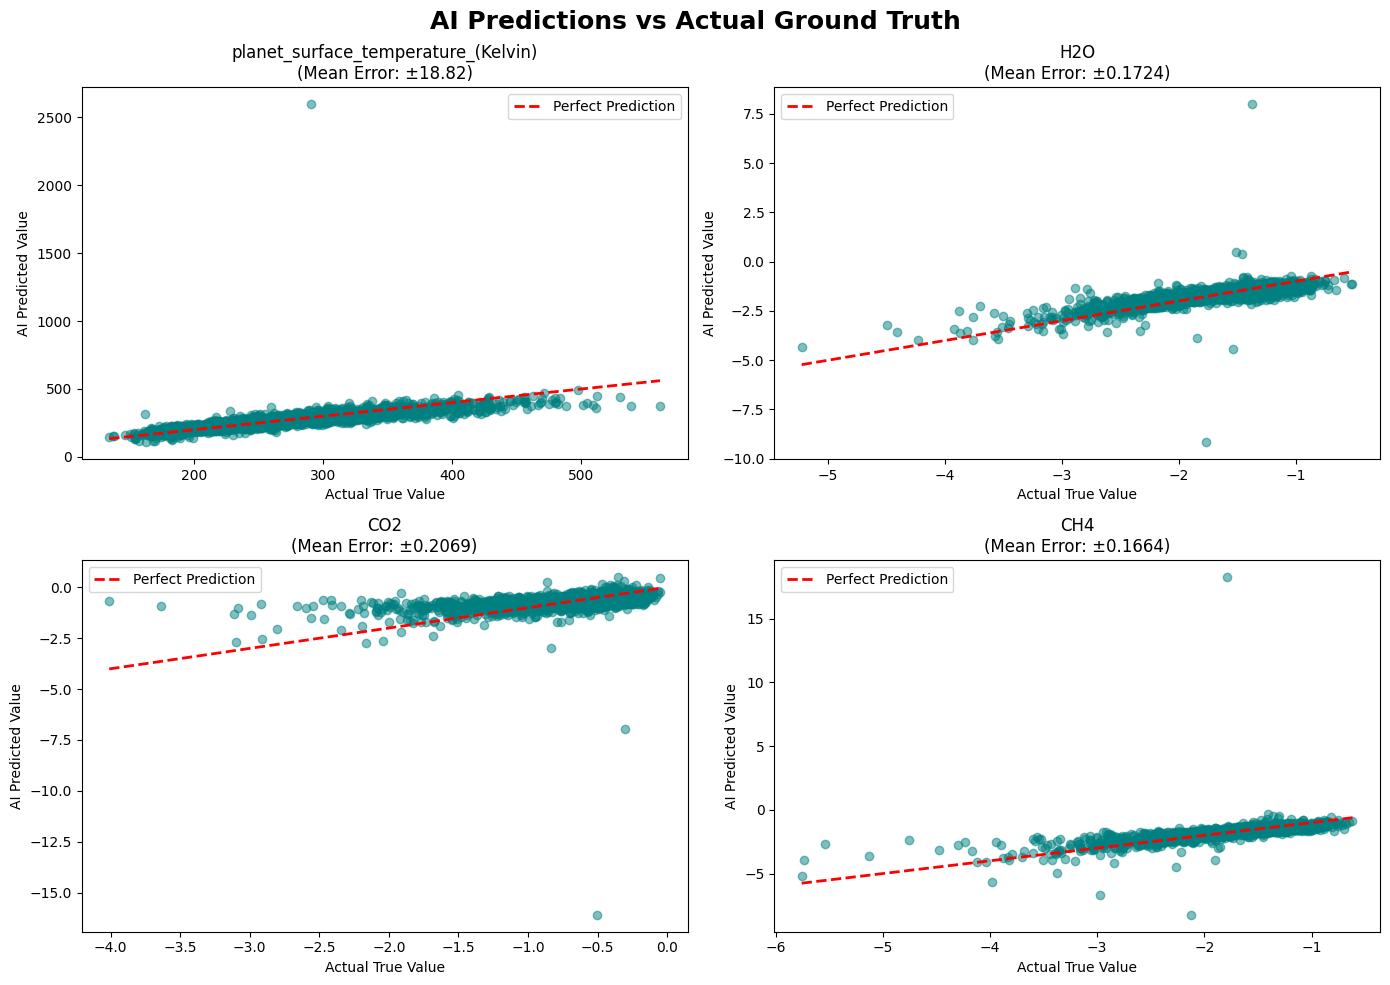

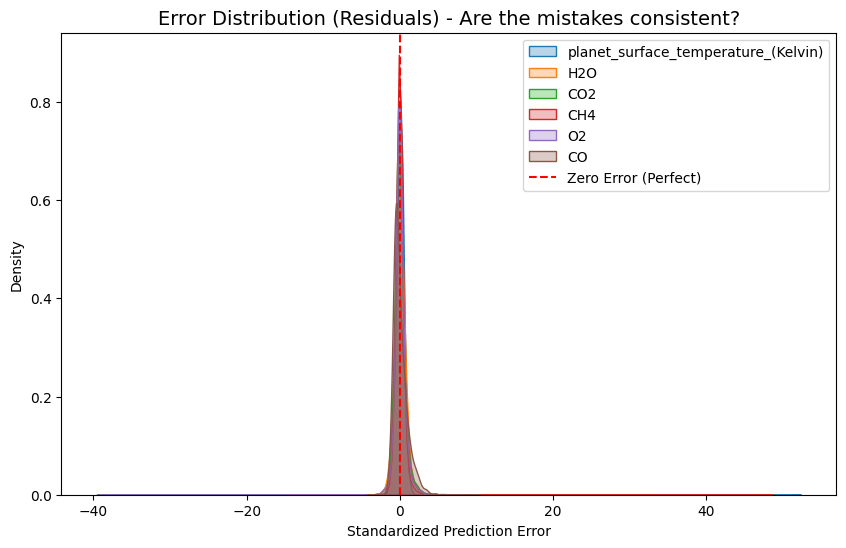

In [38]:
print("Generating predictions on unseen test data...")
# 1. Have the AI make its guesses
y_pred_scaled = model.predict(X_test_cnn)

# 2. Un-scale the data
# THE FIX: Changed 'scaler' to 'scaler_y'
y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# 3. Calculate Global R-Squared Score
r2 = r2_score(y_test_real, y_pred_real)
print(f"\nOverall R-Squared Score: {r2:.4f} (Closer to 1.0 is better!)")

# 4. VISUAL 1: Predicted vs Actual Grid (The Regression "Confusion Matrix")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('AI Predictions vs Actual Ground Truth', fontsize=18, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    if i < len(target_columns):
        # Plot the perfect prediction line (y = x)
        ax.plot([y_test_real[:, i].min(), y_test_real[:, i].max()],
                [y_test_real[:, i].min(), y_test_real[:, i].max()],
                'r--', lw=2, label='Perfect Prediction')

        # Plot the AI's actual guesses
        ax.scatter(y_test_real[:, i], y_pred_real[:, i], alpha=0.5, color='teal')

        target_name = target_columns[i]
        mae = mean_absolute_error(y_test_real[:, i], y_pred_real[:, i])

        ax.set_title(f'{target_name}\n(Mean Error: ±{mae:.4g})')
        ax.set_xlabel('Actual True Value')
        ax.set_ylabel('AI Predicted Value')
        ax.legend()

plt.tight_layout()
plt.show()

# 5. VISUAL 2: Error (Residual) Distribution Curve
plt.figure(figsize=(10, 6))

for i, target in enumerate(target_columns):
    # Calculate the error (difference between guess and truth)
    errors = y_pred_real[:, i] - y_test_real[:, i]
    # Standardize the errors so they fit on the same graph visually
    standardized_errors = errors / np.std(errors)
    sns.kdeplot(standardized_errors, label=target, fill=True, alpha=0.3)

plt.title("Error Distribution (Residuals) - Are the mistakes consistent?", fontsize=14)
plt.xlabel("Standardized Prediction Error")
plt.ylabel("Density")
plt.axvline(0, color='red', linestyle='--', label='Zero Error (Perfect)')
plt.legend()
plt.show()

Converting continuous predictions into Low/Medium/High categories...


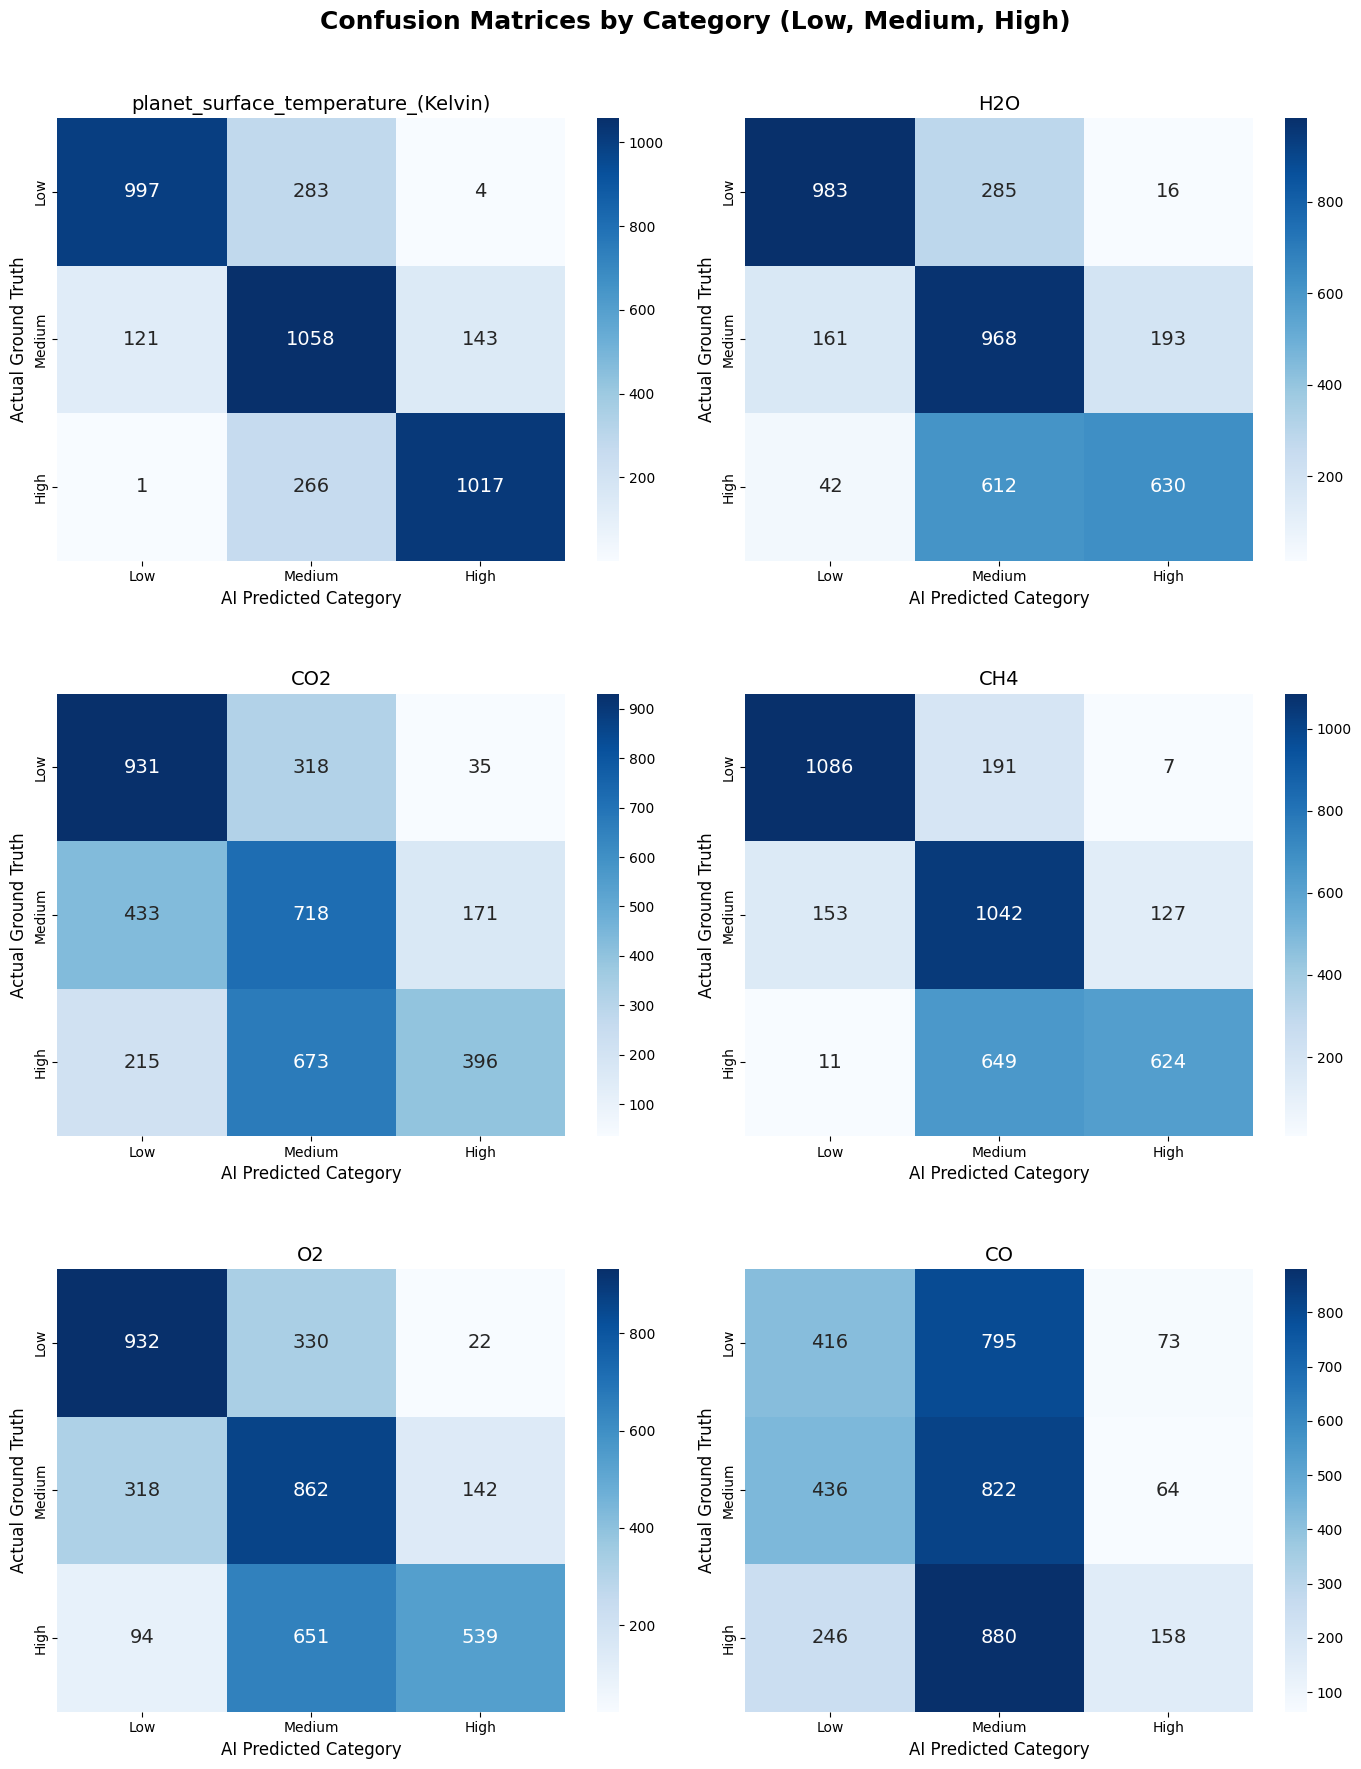

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

print("Converting continuous predictions into Low/Medium/High categories...")

# THE FIX: Changed from (2, 2) to (3, 2) to fit all 6 of your targets.
# Also increased the figsize height from 12 to 18 so it doesn't look squished.
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
fig.suptitle('Confusion Matrices by Category (Low, Medium, High)', fontsize=18, fontweight='bold')

category_labels = ["Low", "Medium", "High"]

for i, target in enumerate(target_columns):
    ax = axes.flatten()[i]

    # Extract the exact numbers for this specific target
    actual_numbers = y_test_real[:, i]
    predicted_numbers = y_pred_real[:, i]

    # Mathematically find the cutoffs for the bottom 33% and top 33% of the real data
    threshold_low = np.percentile(actual_numbers, 33)
    threshold_high = np.percentile(actual_numbers, 67)

    # A quick function to sort numbers into buckets
    def categorize_values(values):
        categories = []
        for val in values:
            if val <= threshold_low:
                categories.append("Low")
            elif val <= threshold_high:
                categories.append("Medium")
            else:
                categories.append("High")
        return categories

    # Convert the numbers into words!
    actual_categories = categorize_values(actual_numbers)
    predicted_categories = categorize_values(predicted_numbers)

    # Generate the standard Confusion Matrix
    cm = confusion_matrix(actual_categories, predicted_categories, labels=category_labels)

    # Paint it beautifully using Seaborn
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=category_labels, yticklabels=category_labels,
                annot_kws={"size": 14}) # Makes the numbers inside the boxes bigger

    ax.set_title(f'{target}', fontsize=14)
    ax.set_ylabel('Actual Ground Truth', fontsize=12)
    ax.set_xlabel('AI Predicted Category', fontsize=12)

plt.tight_layout()
# Adjust layout to make room for the big title
plt.subplots_adjust(top=0.92, hspace=0.3)
plt.show()


--- Categorical Performance Metrics ---

Metrics for: planet_surface_temperature_(Kelvin)
Overall Accuracy: 78.97%

              precision    recall  f1-score   support

         Low       0.89      0.78      0.83      1284
      Medium       0.66      0.80      0.72      1322
        High       0.87      0.79      0.83      1284

    accuracy                           0.79      3890
   macro avg       0.81      0.79      0.79      3890
weighted avg       0.81      0.79      0.79      3890


Metrics for: H2O
Overall Accuracy: 66.35%

              precision    recall  f1-score   support

         Low       0.83      0.77      0.80      1284
      Medium       0.52      0.73      0.61      1322
        High       0.75      0.49      0.59      1284

    accuracy                           0.66      3890
   macro avg       0.70      0.66      0.67      3890
weighted avg       0.70      0.66      0.67      3890


Metrics for: CO2
Overall Accuracy: 52.57%

              precision    recall

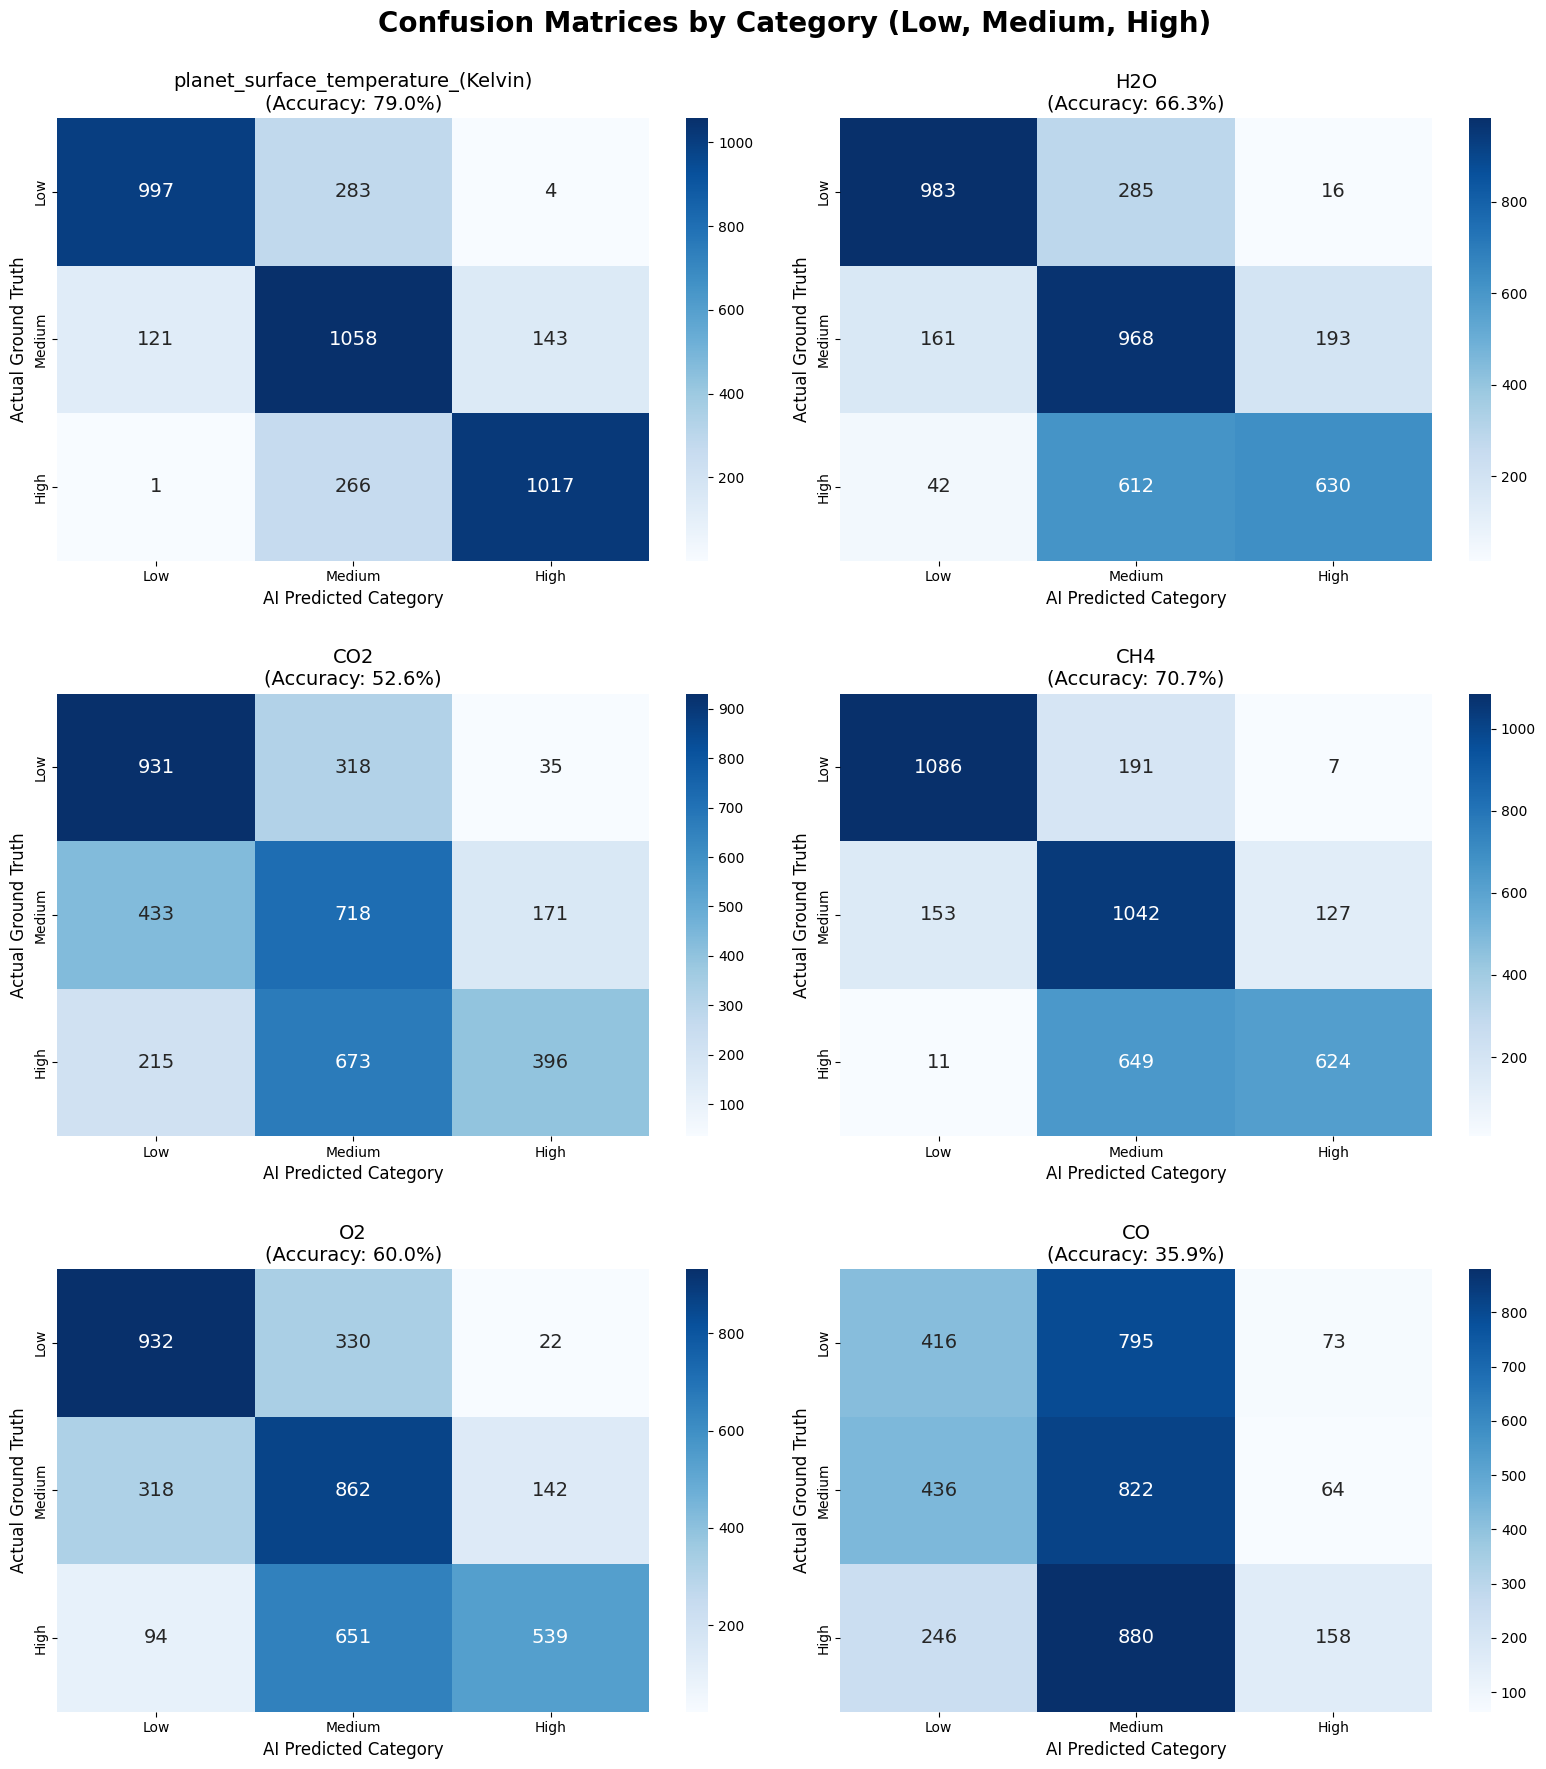

In [40]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("\n--- Categorical Performance Metrics ---")

# Fix: 3x2 grid to accommodate all 6 target columns
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Confusion Matrices by Category (Low, Medium, High)', fontsize=20, fontweight='bold')

category_labels = ["Low", "Medium", "High"]

for i, target in enumerate(target_columns):
    ax = axes.flatten()[i]

    # Extract the exact numbers for this specific target
    actual_numbers = y_test_real[:, i]
    predicted_numbers = y_pred_real[:, i]

    # Mathematically find the cutoffs for the bottom 33% and top 33% of the real data
    threshold_low = np.percentile(actual_numbers, 33)
    threshold_high = np.percentile(actual_numbers, 67)

    # A quick function to sort numbers into buckets
    def categorize_values(values):
        categories = []
        for val in values:
            if val <= threshold_low:
                categories.append("Low")
            elif val <= threshold_high:
                categories.append("Medium")
            else:
                categories.append("High")
        return categories

    # Convert the numbers into words
    actual_categories = categorize_values(actual_numbers)
    predicted_categories = categorize_values(predicted_numbers)

    # --- NEW: Calculate and Print Metrics (Accuracy, F1, Precision, Recall) ---
    print(f"\n=========================================")
    print(f"Metrics for: {target}")
    print(f"=========================================")

    acc = accuracy_score(actual_categories, predicted_categories)
    print(f"Overall Accuracy: {acc * 100:.2f}%\n")

    # The classification report automatically calculates F1, Precision, and Recall for every category
    report = classification_report(actual_categories, predicted_categories, labels=category_labels)
    print(report)

    # --- Generate the Confusion Matrix ---
    cm = confusion_matrix(actual_categories, predicted_categories, labels=category_labels)

    # Paint it beautifully using Seaborn
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=category_labels, yticklabels=category_labels,
                annot_kws={"size": 14}) # Makes the numbers inside the boxes bigger

    ax.set_title(f'{target}\n(Accuracy: {acc * 100:.1f}%)', fontsize=14)
    ax.set_ylabel('Actual Ground Truth', fontsize=12)
    ax.set_xlabel('AI Predicted Category', fontsize=12)

plt.tight_layout()
# Adjust layout to make room for the big title
plt.subplots_adjust(top=0.92, hspace=0.3)
plt.show()

In [41]:
import numpy as np
from sklearn.metrics import accuracy_score

print("\n=========================================")
print("🌍 MODEL-WIDE GLOBAL ACCURACY METRICS 🌍")
print("=========================================\n")

# 1. Create empty grids to hold our categorical words (Low/Medium/High)
y_test_cat_matrix = np.empty_like(y_test_real, dtype=object)
y_pred_cat_matrix = np.empty_like(y_pred_real, dtype=object)

# 2. Fill the grids column by column (Target by Target)
for i in range(len(target_columns)):
    actual_numbers = y_test_real[:, i]
    predicted_numbers = y_pred_real[:, i]

    threshold_low = np.percentile(actual_numbers, 33)
    threshold_high = np.percentile(actual_numbers, 67)

    # A faster, vectorized way to categorize the whole column at once
    y_test_cat_matrix[:, i] = np.where(actual_numbers <= threshold_low, "Low",
                               np.where(actual_numbers <= threshold_high, "Medium", "High"))

    y_pred_cat_matrix[:, i] = np.where(predicted_numbers <= threshold_low, "Low",
                               np.where(predicted_numbers <= threshold_high, "Medium", "High"))

# --- Metric 1: Average Target Accuracy ---
accuracies = [accuracy_score(y_test_cat_matrix[:, i], y_pred_cat_matrix[:, i]) for i in range(len(target_columns))]
average_accuracy = np.mean(accuracies)

# --- Metric 2: Global Flattened Accuracy ---
# Flattens the grids into two giant single lists and compares them
global_accuracy = accuracy_score(y_test_cat_matrix.flatten(), y_pred_cat_matrix.flatten())

# --- Metric 3: Exact Match Ratio (Perfect Planets) ---
# Checks row-by-row: Did the AI get ALL 6 targets right for this specific planet?
exact_matches = np.all(y_test_cat_matrix == y_pred_cat_matrix, axis=1)
exact_match_ratio = np.mean(exact_matches)

# Print the final scorecard
print(f"1. Average Target Accuracy : {average_accuracy * 100:.2f}%")
print(f"   (The average score across your 6 individual targets)\n")

print(f"2. Global Accuracy         : {global_accuracy * 100:.2f}%")
print(f"   (Out of all predictions made, how many were right?)\n")

print(f"3. Exact Match Ratio       : {exact_match_ratio * 100:.2f}%")
print(f"   (Strict: How many planets did the AI guess 100% perfectly on ALL 6 traits?)\n")


🌍 MODEL-WIDE GLOBAL ACCURACY METRICS 🌍

1. Average Target Accuracy : 60.75%
   (The average score across your 6 individual targets)

2. Global Accuracy         : 60.75%
   (Out of all predictions made, how many were right?)

3. Exact Match Ratio       : 5.19%
   (Strict: How many planets did the AI guess 100% perfectly on ALL 6 traits?)



In [42]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("\n=========================================")
print("📈 CONTINUOUS REGRESSION METRICS 📈")
print("=========================================\n")

# Calculate global R2 across everything
global_r2 = r2_score(y_test_real, y_pred_real)
print(f"GLOBAL R-SQUARED SCORE: {global_r2:.4f}\n")
print("Breakdown by individual target:")
print("-" * 40)

for i, target in enumerate(target_columns):
    # Extract the exact numbers for this specific target
    actual_vals = y_test_real[:, i]
    pred_vals = y_pred_real[:, i]

    # Calculate the continuous math metrics
    r2 = r2_score(actual_vals, pred_vals)
    mae = mean_absolute_error(actual_vals, pred_vals)
    rmse = np.sqrt(mean_squared_error(actual_vals, pred_vals))

    print(f"Target: {target}")
    print(f"  R-Squared (R2)     : {r2:.4f}")
    print(f"  Mean Abs Error(MAE): {mae:.4f}")
    print(f"  Root Mean Sq (RMSE): {rmse:.4f}\n")


📈 CONTINUOUS REGRESSION METRICS 📈

GLOBAL R-SQUARED SCORE: 0.1685

Breakdown by individual target:
----------------------------------------
Target: planet_surface_temperature_(Kelvin)
  R-Squared (R2)     : 0.4354
  Mean Abs Error(MAE): 18.8171
  Root Mean Sq (RMSE): 44.5297

Target: H2O
  R-Squared (R2)     : 0.5213
  Mean Abs Error(MAE): 0.1724
  Root Mean Sq (RMSE): 0.3027

Target: CO2
  R-Squared (R2)     : -0.1304
  Mean Abs Error(MAE): 0.2069
  Root Mean Sq (RMSE): 0.3998

Target: CH4
  R-Squared (R2)     : 0.2528
  Mean Abs Error(MAE): 0.1664
  Root Mean Sq (RMSE): 0.4170

Target: O2
  R-Squared (R2)     : -0.0144
  Mean Abs Error(MAE): 0.1912
  Root Mean Sq (RMSE): 0.4014

Target: CO
  R-Squared (R2)     : -0.0535
  Mean Abs Error(MAE): 0.3456
  Root Mean Sq (RMSE): 0.4778

